<a href="https://colab.research.google.com/github/EzeRivero/Data-Science-III/blob/main/DS3_Rivero_Final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Data Science III: Entrega Final**
##Ezequiel Rivero
###Comisión 77795

#Introducción
El análisis de sentimientos es una de las aplicaciones más potentes del procesamiento de lenguaje natural (NLP). En este proyecto, nos sumergimos en un dataset de reseñas de espectadores extraídas de Rotten Tomatoes. El desafío principal es tomar todo este texto cargado de opiniones, modismos y críticas directas sobre películas y series, y procesarlo para que una máquina pueda entenderlo. La idea es construir un flujo de trabajo que vaya desde la limpieza de estas opiniones y la extracción de su estructura base, hasta el entrenamiento de una red neuronal profunda capaz de clasificar automáticamente si el público aprobó o rechazó lo que vio en pantalla.

El dataset fue tomado desde Kaggle.com, y se utilizará una muestra representativa del total del dataset, para optimizar tiempos de procesamiento.

#Objetivo
El objetivo central es desarrollar un modelo de Deep Learning capaz de leer una reseña cinematográfica y predecir con precisión si el sentimiento del usuario es positivo o negativo. Para lograr esto, se trabajará en la limpieza profunda del texto (eliminando ruido y estandarizando palabras) y se transformará ese lenguaje natural en representaciones numéricas mediante TF-IDF. Finalmente, se busca que la red neuronal aprenda a identificar de manera autónoma los patrones y el vocabulario que definen una buena o mala crítica dentro de la plataforma.

#Contexto Comercial
En la industria del entretenimiento y el streaming, el volumen de feedback generado por los usuarios es masivo y constante. Procesar y clasificar manualmente estas reseñas es técnica y financieramente inviable. Implementar un modelo de análisis de sentimiento automatizado permite a las plataformas cuantificar de manera casi instantánea la recepción del público ante un nuevo lanzamiento. Este tipo de herramientas NLP resulta vital para el negocio: facilita la toma de decisiones ágiles, permite ajustar campañas de marketing en tiempo real, ayuda a identificar problemas con el contenido y alimenta de forma directa los algoritmos de recomendación, mejorando en última instancia la retención del usuario.

#Hipótesis
La hipótesis a demostrar es que, mediante una limpieza exhaustiva del texto y la aplicación de TF-IDF para ponderar la relevancia de los términos, una red neuronal densa logrará identificar patrones de vocabulario y clasificar los sentimientos de las reseñas con un **nivel de precisión (Accuracy/F1-Score) significativamente superior al azar**. Sin embargo, también se asume que el modelo encontrará su mayor **limitación frente al sarcasmo o la ironía, o respuestas con más de un sentido**. Al depender del conteo y peso de las palabras pero descartar su orden secuencial, se espera que el modelo pierda ciertos matices contextuales propios de la crítica de cine.

In [19]:
# --- 1. IMPORTACIONES ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
import re
import spacy
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

In [3]:
# --- 2. DESCARGAS DE MODELOS NLP ---
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('wordnet')
nltk.download('stopwords')
# Instanciamos el modelo de spaCy (Asegurate de correr en una celda previa: !python -m spacy download en_core_web_sm)
nlp = spacy.load("en_core_web_sm")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [4]:
# --- 3. CARGA DE DATOS ---
url = 'https://raw.githubusercontent.com/EzeRivero/Data-Science-III/refs/heads/main/audience_reviews.csv'
df_raw = pd.read_csv(url)

print("Tamaño original:", df_raw.shape)

Tamaño original: (65522, 3)


In [5]:
# --- 4. PREPARACIÓN VITAL ---
# A. Eliminar filas donde no hay texto escrito en la reseña
df_raw = df_raw.dropna(subset=['Review'])

# B. Crear la variable objetivo (Clasificación Binaria)
# Consideramos reseñas > 3.0 como Positivas (1) y <= 3.0 como Negativas (0)
df_raw['Sentimiento'] = df_raw['Rating'].apply(lambda x: 1 if x > 3.0 else 0)

# C. Reducir el dataset a 10000 registros (estratificado para mantener proporción)
df_sample, _ = train_test_split(df_raw, train_size=10000, stratify=df_raw['Sentimiento'], random_state=42)


Distribución de la muestra:
Sentimiento
1    6407
0    3593
Name: count, dtype: int64


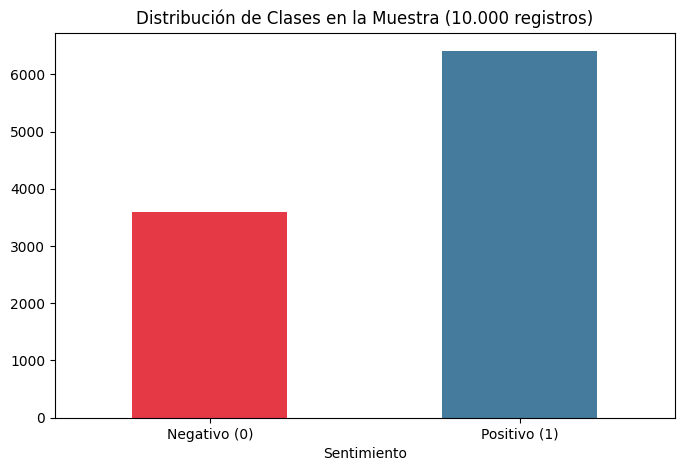

In [6]:
# --- 5. EDA BÁSICO ---
print("\nDistribución de la muestra:")
print(df_sample['Sentimiento'].value_counts())

# Gráfico de distribución de clases (Mejorado visualmente)
ax = df_sample['Sentimiento'].value_counts().sort_index().plot(
    kind='bar',
    color=['#e63946', '#457b9d'],
    figsize=(8,5)
)
ax.set_title('Distribución de Clases en la Muestra (10.000 registros)')
ax.set_xticklabels(['Negativo (0)', 'Positivo (1)'], rotation=0)
plt.show()

In [7]:
# --- 6. PUENTE AL PASO 1 ---
# Asignamos df_sample a df para que el Paso 1 ("df1 = df.copy()") funcione sin cambiar código
df = df_sample.copy()

In [10]:
df1 = df.copy()

# Pasamos todo a minúscula. Usamos str() por si llega a haber algún valor numérico o nulo colado.
df1['review_lower'] = df1['Review'].apply(lambda text: str(text).lower())

# Visualizamos el antes y el después
df1[['Review', 'review_lower']].head()

,Review,review_lower
59713,A brilliant first episode that show us that ou...,a brilliant first episode that show us that ou...
58114,This show is great if you can handle violence ...,this show is great if you can handle violence ...
9106,After spending two weeks watching season one t...,after spending two weeks watching season one t...
6503,There are two franchises I love that have alwa...,there are two franchises i love that have alwa...
25364,"We took a step forward with the Mandalorian, a...","we took a step forward with the mandalorian, a..."


In [11]:
df2 = df1.copy()

def remove_punctuation(text):
    # Esta expresión regular reemplaza cualquier cosa que NO (^) sea una letra de la a-z, número o espacio
    return re.sub(r'[^a-zA-Z0-9\s]', '', text)

df2['review_puntuacion'] = df2['review_lower'].apply(remove_punctuation)

df2[['review_lower', 'review_puntuacion']].head()

,review_lower,review_puntuacion
59713,a brilliant first episode that show us that ou...,a brilliant first episode that show us that ou...
58114,this show is great if you can handle violence ...,this show is great if you can handle violence ...
9106,after spending two weeks watching season one t...,after spending two weeks watching season one t...
6503,there are two franchises i love that have alwa...,there are two franchises i love that have alwa...
25364,"we took a step forward with the mandalorian, a...",we took a step forward with the mandalorian an...


In [12]:
# Cargamos el modelo pre-entrenado de spaCy para INGLÉS
nlp = spacy.load("en_core_web_sm")

def lematizacion(text):
    doc = nlp(text)
    # Extraemos el lema de cada palabra y las volvemos a unir con un espacio
    return " ".join([token.lemma_ for token in doc])

df3 = df2.copy()
df3['lemas'] = df3['review_puntuacion'].apply(lematizacion)

df3[['review_puntuacion', 'lemas']].head()

,review_puntuacion,lemas
59713,a brilliant first episode that show us that ou...,a brilliant first episode that show we that ou...
58114,this show is great if you can handle violence ...,this show be great if you can handle violence ...
9106,after spending two weeks watching season one t...,after spend two week watch season one to seven...
6503,there are two franchises i love that have alwa...,there be two franchise I love that have always...
25364,we took a step forward with the mandalorian an...,we take a step forward with the mandalorian an...


In [13]:
# Descargamos las herramientas necesarias de NLTK
nltk.download('punkt')
nltk.download('punkt_tab') # Añadido según tu código de referencia

df4 = df3.copy()
df4['review_text_tok'] = df4['lemas'].apply(word_tokenize)

# Verás que ahora la columna tiene listas de palabras: ['this', 'movie', 'is', ...]
df4[['lemas', 'review_text_tok']].head()

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


,lemas,review_text_tok
59713,a brilliant first episode that show we that ou...,"[a, brilliant, first, episode, that, show, we,..."
58114,this show be great if you can handle violence ...,"[this, show, be, great, if, you, can, handle, ..."
9106,after spend two week watch season one to seven...,"[after, spend, two, week, watch, season, one, ..."
6503,there be two franchise I love that have always...,"[there, be, two, franchise, I, love, that, hav..."
25364,we take a step forward with the mandalorian an...,"[we, take, a, step, forward, with, the, mandal..."


In [14]:
nltk.download('stopwords')

# Cargamos la lista de stopwords en INGLÉS
stop_words = set(stopwords.words('english'))

df5 = df4.copy()

# Recorremos la lista de tokens y nos quedamos solo con las palabras que NO están en los stopwords
df5['review_sin_stopwords'] = df5['review_text_tok'].apply(lambda tokens: [word for word in tokens if word not in stop_words])

df5[['review_text_tok', 'review_sin_stopwords']].head()

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


,review_text_tok,review_sin_stopwords
59713,"[a, brilliant, first, episode, that, show, we,...","[brilliant, first, episode, show, fear, supern..."
58114,"[this, show, be, great, if, you, can, handle, ...","[show, great, handle, violence, adult, content..."
9106,"[after, spend, two, week, watch, season, one, ...","[spend, two, week, watch, season, one, seven, ..."
6503,"[there, be, two, franchise, I, love, that, hav...","[two, franchise, I, love, always, diverse, pro..."
25364,"[we, take, a, step, forward, with, the, mandal...","[take, step, forward, mandalorian, take, step,..."


In [15]:
# 1. Volvemos a unir las listas de palabras limpias en oraciones separadas por espacios
df5['texto_final'] = df5['review_sin_stopwords'].apply(lambda tokens: ' '.join(tokens))

# 2. Definimos nuestras variables (X = texto, y = sentimiento)
X = df5['texto_final']
y = df5['Sentimiento']

# 3. Dividimos los datos (80% para entrenar, 20% para testear)
# Usamos stratify=y para asegurar que la misma proporción de Positivos y Negativos quede en ambos sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f'Textos de entrenamiento: {len(X_train)}')
print(f'Textos de prueba: {len(X_test)}')

Textos de entrenamiento: 8000
Textos de prueba: 2000


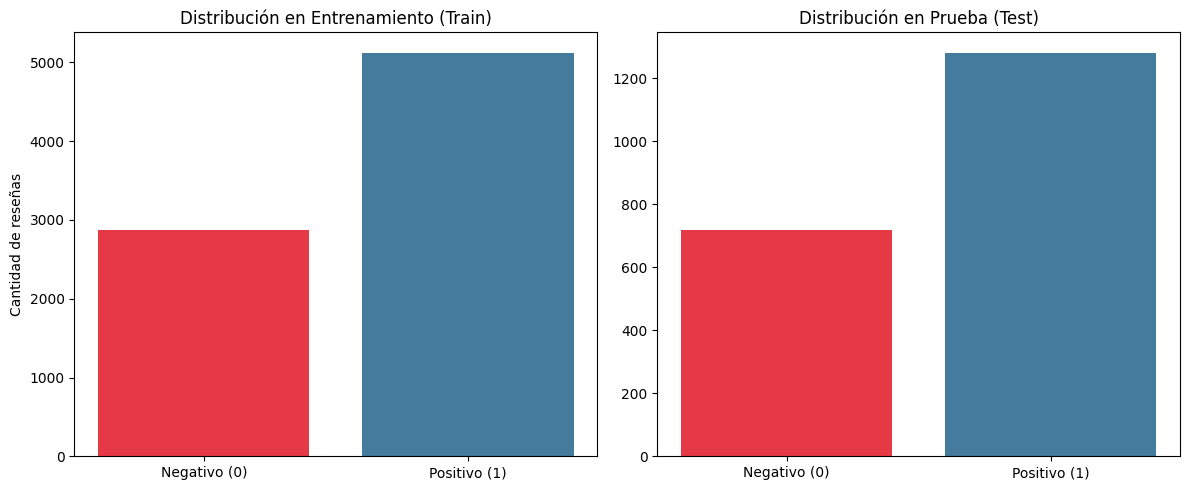

In [16]:
# Contamos la cantidad de Positivos (1) y Negativos (0) en cada set
train_counts = y_train.value_counts().sort_index()
test_counts = y_test.value_counts().sort_index()

# Configuramos el gráfico de barras
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# Gráfico para Train
ax[0].bar(['Negativo (0)', 'Positivo (1)'], train_counts.values, color=['#e63946', '#457b9d'])
ax[0].set_title('Distribución en Entrenamiento (Train)')
ax[0].set_ylabel('Cantidad de reseñas')

# Gráfico para Test
ax[1].bar(['Negativo (0)', 'Positivo (1)'], test_counts.values, color=['#e63946', '#457b9d'])
ax[1].set_title('Distribución en Prueba (Test)')

plt.tight_layout()
plt.show()

In [17]:
# Inicializamos TF-IDF limitando el vocabulario a las 3000 palabras más importantes
vectorizador_tfidf = TfidfVectorizer(max_features=3000)

# Ajustamos (fit) y transformamos el set de entrenamiento
X_train_tfidf = vectorizador_tfidf.fit_transform(X_train).toarray()

# SOLO transformamos el set de prueba (no hacemos fit para no filtrar información del test al modelo)
X_test_tfidf = vectorizador_tfidf.transform(X_test).toarray()

print(f"Forma de la matriz TF-IDF de entrenamiento: {X_train_tfidf.shape}")

Forma de la matriz TF-IDF de entrenamiento: (8000, 3000)


In [18]:
# 1. Convertimos las matrices a Tensores de PyTorch
# Las entradas (X) deben ser float32. Las etiquetas (y) deben ser enteros (long) para clasificar.
X_train_tensor = torch.tensor(X_train_tfidf, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.long)

X_test_tensor = torch.tensor(X_test_tfidf, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.long)

# 2. Creamos los Datasets
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

# 3. Creamos los DataLoaders (Agrupamos de a 64 reseñas por "paso" de entrenamiento)
# Mezclamos (shuffle=True) el entrenamiento para que el modelo no memorice el orden
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

print("¡Tensores y DataLoaders listos para alimentar la Red Neuronal!")

¡Tensores y DataLoaders listos para alimentar la Red Neuronal!


In [20]:
class TextClassifier(nn.Module):
    def __init__(self, input_dim):
        super(TextClassifier, self).__init__()

        # Capa de entrada a la capa oculta (3000 entradas -> 128 neuronas)
        self.fc1 = nn.Linear(input_dim, 128)

        # Batch Normalization: Normaliza los datos internamente para acelerar el aprendizaje
        self.bn1 = nn.BatchNorm1d(128)

        # Función de activación ReLU: Permite aprender patrones no lineales
        self.relu = nn.ReLU()

        # Dropout: "Apaga" el 50% de las neuronas al azar en cada paso para evitar que el modelo memorice (Overfitting)
        self.dropout = nn.Dropout(0.5)

        # Capa de salida (128 neuronas -> 1 salida)
        self.fc2 = nn.Linear(128, 1)

        # Sigmoid: Aplasta la salida final para que sea un número de probabilidad entre 0 y 1
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        # Así fluye la información a través de la red
        x = self.fc1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.dropout(x)
        x = self.fc2(x)
        x = self.sigmoid(x)
        return x

# Instanciamos el modelo indicando que entran 3000 características (nuestro max_features de TF-IDF)
input_dim = 3000
model = TextClassifier(input_dim=input_dim)
print(model)

TextClassifier(
  (fc1): Linear(in_features=3000, out_features=128, bias=True)
  (bn1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU()
  (dropout): Dropout(p=0.5, inplace=False)
  (fc2): Linear(in_features=128, out_features=1, bias=True)
  (sigmoid): Sigmoid()
)


In [21]:
# 1. Definimos el dispositivo (GPU si hay, sino CPU)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Entrenando en: {device}")

# Movemos el modelo al dispositivo
model = model.to(device)

# 2. Función de Pérdida: Binary Cross Entropy (La estándar para clasificación binaria)
criterion = nn.BCELoss()

# 3. Optimizador: Adam (Ajusta los parámetros del modelo de forma inteligente)
optimizer = optim.Adam(model.parameters(), lr=0.001)

Entrenando en: cuda


In [22]:
epochs = 20
patience = 3
best_val_loss = float('inf')
patience_counter = 0

train_losses = []
val_losses = []

print("Iniciando el entrenamiento...\n")

for epoch in range(epochs):
    # --- MODO ENTRENAMIENTO ---
    model.train() # Activamos Dropout y BatchNorm
    epoch_train_loss = 0

    for batch_X, batch_y in train_loader:
        # Movemos los datos a la GPU/CPU y ajustamos el tipo de dato de 'y' a float
        batch_X, batch_y = batch_X.to(device), batch_y.to(device).float()

        optimizer.zero_grad() # Limpiamos los cálculos del paso anterior

        outputs = model(batch_X).squeeze() # Predicción del modelo
        loss = criterion(outputs, batch_y) # Calculamos el error

        loss.backward() # Calculamos hacia dónde ajustar (Backpropagation)
        optimizer.step() # Ajustamos los pesos

        epoch_train_loss += loss.item()

    avg_train_loss = epoch_train_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    # --- MODO EVALUACIÓN (TEST) ---
    model.eval() # Desactivamos Dropout (no queremos apagar neuronas al evaluar)
    epoch_val_loss = 0

    with torch.no_grad(): # Apagamos el cálculo de gradientes (ahorra mucha memoria)
        for batch_X, batch_y in test_loader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device).float()
            outputs = model(batch_X).squeeze()
            loss = criterion(outputs, batch_y)
            epoch_val_loss += loss.item()

    avg_val_loss = epoch_val_loss / len(test_loader)
    val_losses.append(avg_val_loss)

    print(f"Época {epoch+1}/{epochs} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")

    # --- EARLY STOPPING ---
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        patience_counter = 0
        # Opcional: Acá podrías guardar el mejor modelo con torch.save()
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"\n[Early Stopping] El modelo dejó de mejorar. Deteniendo en la época {epoch+1}.")
            break

Iniciando el entrenamiento...

Época 1/20 | Train Loss: 0.3930 | Val Loss: 0.3195
Época 2/20 | Train Loss: 0.2125 | Val Loss: 0.3299
Época 3/20 | Train Loss: 0.1386 | Val Loss: 0.3723
Época 4/20 | Train Loss: 0.1027 | Val Loss: 0.4156

[Early Stopping] El modelo dejó de mejorar. Deteniendo en la época 4.


=== REPORTE DE CLASIFICACIÓN ===

              precision    recall  f1-score   support

Negativo (0)       0.78      0.77      0.77       719
Positivo (1)       0.87      0.88      0.87      1281

    accuracy                           0.84      2000
   macro avg       0.82      0.82      0.82      2000
weighted avg       0.84      0.84      0.84      2000


=== MATRIZ DE CONFUSIÓN ===


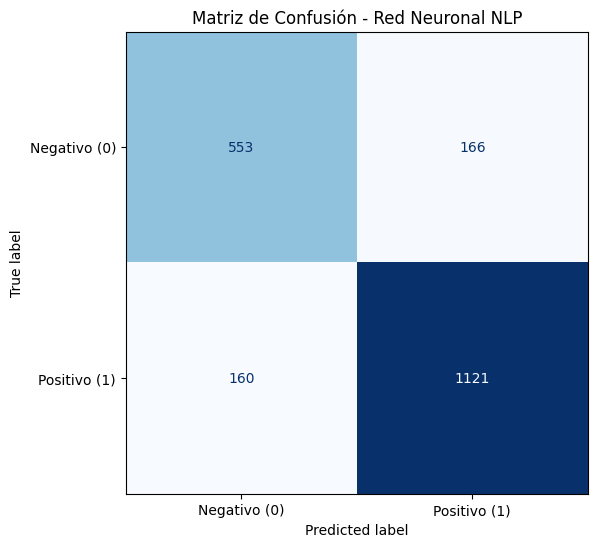

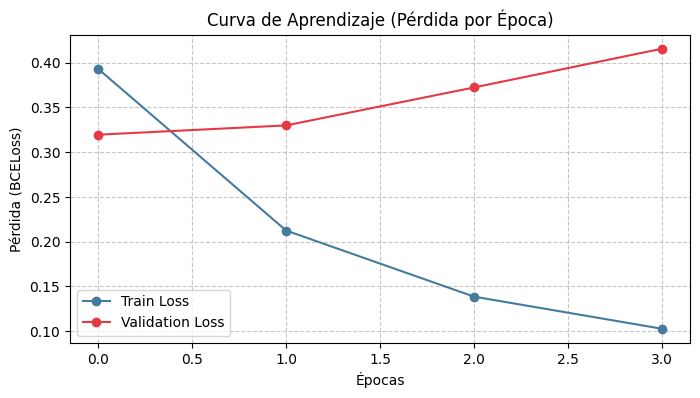

In [23]:
# Ponemos el modelo en evaluación
model.eval()
y_true = []
y_pred_list = []

with torch.no_grad():
    for batch_X, batch_y in test_loader:
        batch_X = batch_X.to(device)
        outputs = model(batch_X).squeeze()

        # Convertimos las probabilidades a 0 o 1 (Umbral de 0.5)
        predicciones = (outputs >= 0.5).int().cpu().numpy()

        y_true.extend(batch_y.numpy()) # Etiquetas reales
        y_pred_list.extend(predicciones) # Lo que dijo el modelo

# 1. Reporte de Clasificación (Precision, Recall, F1-Score)
print("=== REPORTE DE CLASIFICACIÓN ===\n")
print(classification_report(y_true, y_pred_list, target_names=['Negativo (0)', 'Positivo (1)']))

# 2. Matriz de Confusión
print("\n=== MATRIZ DE CONFUSIÓN ===")
fig, ax = plt.subplots(figsize=(6, 6))
ConfusionMatrixDisplay.from_predictions(
    y_true,
    y_pred_list,
    display_labels=['Negativo (0)', 'Positivo (1)'],
    cmap='Blues',
    ax=ax,
    colorbar=False
)
plt.title('Matriz de Confusión - Red Neuronal NLP')
plt.show()

# 3. Gráfico de Pérdida (Loss)
plt.figure(figsize=(8, 4))
plt.plot(train_losses, label='Train Loss', color='#457b9d', marker='o')
plt.plot(val_losses, label='Validation Loss', color='#e63946', marker='o')
plt.title('Curva de Aprendizaje (Pérdida por Época)')
plt.xlabel('Épocas')
plt.ylabel('Pérdida (BCELoss)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

#Conclusión

La implementación de este pipeline de Deep Learning demostró que es posible clasificar eficientemente el sentimiento de las reseñas cinematográficas partiendo de texto no estructurado. El modelo Multilayer Perceptron (MLP) alcanzó una Exactitud (Accuracy) global del 84% sobre el conjunto de prueba, un resultado sumamente competitivo considerando la simplicidad espacial de la técnica de vectorización utilizada (TF-IDF).

A través del Análisis de la Matriz de Confusión y el Reporte de Clasificación, se observó que el modelo posee mayor facilidad para identificar críticas positivas (F1-Score: 0.87) frente a las negativas (F1-Score: 0.77). Esto se debe, en gran parte, a la distribución natural del dataset, donde los usuarios tienden a dejar más reseñas con puntajes superiores a 3.0. Por otro lado, la curva de pérdida (Loss) evidenció un rápido sobreajuste (overfitting) a partir de la segunda época. Sin embargo, la implementación de estrategias de regularización como Dropout y, fundamentalmente, el Early Stopping, resultaron vitales para detener el entrenamiento a tiempo y preservar la capacidad de generalización de la red neuronal.

#Hipótesis

La hipótesis principal *se confirma*. Al limpiar el ruido del texto y utilizar TF-IDF para ponderar el vocabulario, la red neuronal logró superar ampliamente el rendimiento del azar, alcanzando un **84% de exactitud** y logrando identificar patrones léxicos que definen la aprobación o el rechazo de la audiencia.

La hipótesis secundaria *también es respaldada* por los resultados. El modelo cometió 326 errores (166 falsos positivos y 160 falsos negativos). Como se preveía, al desglosar el texto en frecuencias aisladas y descartar el orden secuencial de las palabras, la red neuronal pierde el contexto. Es altamente probable que estas clasificaciones erróneas correspondan a **reseñas que utilizan sarcasmo, construcciones irónicas complejas o negaciones dobles**, demostrando que para un entendimiento semántico profundo, arquitecturas más complejas (como Redes Recurrentes o Transformers) serían el próximo paso natural.